In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('matches.csv')
data.shape

(756, 18)

In [4]:
data.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


### Compare Virat Kohli and MS Dhoni

In [5]:
df=pd.DataFrame(data['player_of_match'].value_counts()).reset_index(drop=False)
df.columns=['player','times_won_p_of_match']
xy=df.loc[(df['player'].isin(['V Kohli','MS Dhoni']))]
x=xy['times_won_p_of_match']
labels=[f"{k} won player \nof the game {v} times" for k,v in zip(xy['player'],x)]


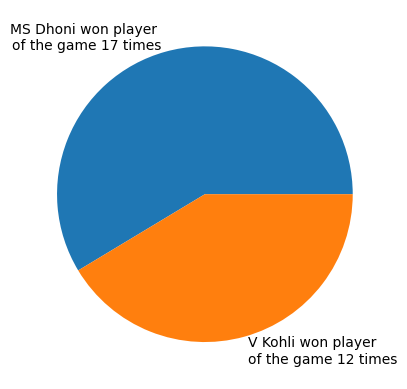

In [6]:
plt.pie(x=x,labels=labels)
plt.show()

### Find out Toughest IPL Matches

In [7]:
n=100
wbw=data.loc[data['win_by_wickets']==1].sort_values(by='win_by_wickets',ascending=True).head(n)
wbr=data.loc[data['win_by_runs']==1].sort_values(by='win_by_runs',ascending=True).head(n)
toughest=pd.concat([wbw,wbr]).reset_index(drop=True)
toughest[['Season','venue','team1','team2','win_by_runs','win_by_wickets','winner']].style.background_gradient(cmap='BrBG')

,Season,venue,team1,team2,win_by_runs,win_by_wickets,winner
0,IPL-2015,Eden Gardens,Kings XI Punjab,Kolkata Knight Riders,0,1,Kolkata Knight Riders
1,IPL-2018,Wankhede Stadium,Mumbai Indians,Chennai Super Kings,0,1,Chennai Super Kings
2,IPL-2018,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Sunrisers Hyderabad,0,1,Sunrisers Hyderabad
3,IPL-2017,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,1,0,Mumbai Indians
4,IPL-2008,Wankhede Stadium,Kings XI Punjab,Mumbai Indians,1,0,Kings XI Punjab
5,IPL-2009,New Wanderers Stadium,Kings XI Punjab,Deccan Chargers,1,0,Kings XI Punjab
6,IPL-2012,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,1,0,Delhi Daredevils
7,IPL-2012,Subrata Roy Sahara Stadium,Mumbai Indians,Pune Warriors,1,0,Mumbai Indians
8,IPL-2015,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Delhi Daredevils,1,0,Chennai Super Kings
9,IPL-2016,Feroz Shah Kotla,Gujarat Lions,Delhi Daredevils,1,0,Gujarat Lions


### Find out the Matches where Dhoni was Player of the Match but the Team Lost  
> my result is different from the homework solutions because I used wikipedia to find the years MS Dhoni was on which teams. The solutions assumes MS Dhoni always played for Chennai Super Kings. Wikipedia doesn't agree

In [8]:
data['date']=pd.to_datetime(data['date'],dayfirst=True)

for col in ['team1','team2','toss_winner','winner']:
    data[col]=data[col].replace({'Rising Pune Supergiant':'Rising Pune Supergiants'})

lookup={(2008,2015):'Chennai Super Kings',(2016,2017):'Rising Pune Supergiants',(2018,2020):'Chennai Super Kings'}
dhoni_pog_still_lost=[]
data['temp']=(data['Season'].str.split('-').str[-1]).astype(int)
for k,v in lookup.items():
    team=v
    for year in range(k[0],k[1]+1):
        occurance=data.loc[(data['player_of_match']=='MS Dhoni')&(data['winner']!=team)&(data['temp']==year)]
        if occurance.shape[0]>0:
            occurance["MS Dhoni's team"]=team
            dhoni_pog_still_lost.append(occurance)
        del occurance
    del team
data.drop(columns='temp',inplace=True)
result = "None" if not dhoni_pog_still_lost  else dhoni_pog_still_lost[0][['Season','venue','team1','team2','player_of_match','winner',"MS Dhoni's team"]] if len(dhoni_pog_still_lost) < 2 else pd.concat(dhoni_pog_still_lost)[['Season','venue','team1','team2','player_of_match','winner',"MS Dhoni's team"]]
if result=="None":
    print("There are no games to report")
else: display(result)

There are no games to report


The following cell was coppied from the solutions and is not correct

In [9]:
#copied from solution
data[(data['player_of_match'] == 'MS Dhoni') & 
     (data['winner'] != 'Chennai Super Kings')][['team1','team2','winner']].reset_index(drop = True)

,team1,team2,winner
0,Sunrisers Hyderabad,Rising Pune Supergiants,Rising Pune Supergiants
1,Kings XI Punjab,Rising Pune Supergiants,Rising Pune Supergiants
